#### Imports

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from oemof import solph
from oemof.tools import economics
from oemof.solph import processing, views
import pyomo.environ as pyo
import plotly.graph_objects as go

In [2]:
full_filename = os.path.join('exam_project_profiles.csv')
input_data = pd.read_csv(full_filename)
input_data.rename(columns={"0": "Time"}, inplace=True)

## Peak demand curves

<Axes: title={'center': 'Peak electricity demand curve'}, xlabel='Time', ylabel='Power kW'>

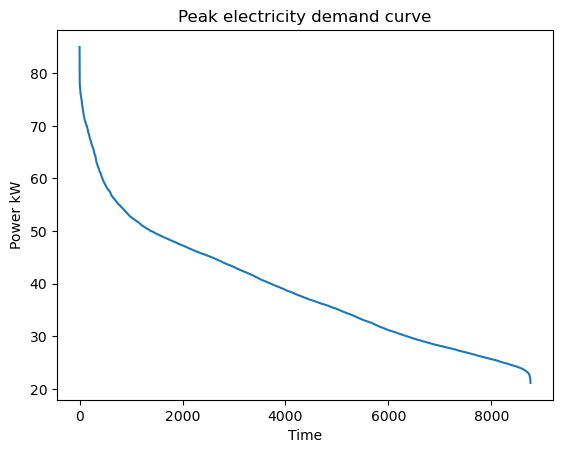

In [3]:
input_data["Pel_demand_sorted"].plot(ylabel='Power kW',xlabel='Time',title='Peak electricity demand curve')

<Axes: title={'center': 'Peal Heat demand curve'}, xlabel='Time', ylabel='Power (kW)'>

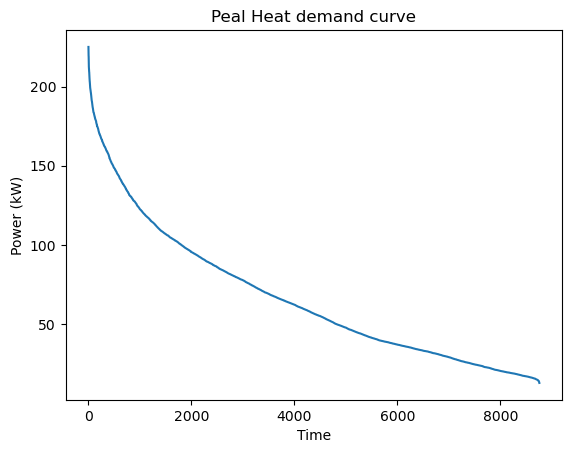

In [4]:
input_data["Pth_demand_sorted"].plot(ylabel='Power (kW)',xlabel='Time',title='Peal Heat demand curve')

#### Total energy demand and generation calculation

In [5]:
Pel_total = input_data["Pel_demand (kW)"].sum()
Pth_total = input_data["Pth_demand (kW)"].sum()
Pel_solar_total = input_data["P_solar_total (kW)"].sum()
print("Total electricity demand without heat pump:",Pel_total)
print("Total heat demand :",Pth_total)
print("Total solar power generated :",Pel_solar_total)

Total electricity demand without heat pump: 341964.3068294984
Total heat demand : 584786.5600148749
Total solar power generated : 1739516.22227


<Axes: title={'center': 'Peak Total Electricity demand curve'}, xlabel='Time', ylabel='Power (kW)'>

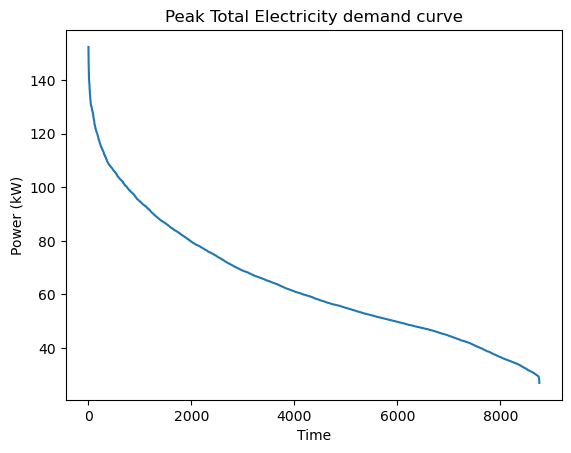

In [6]:
input_data["Pel_demand_total_sorted"].plot(xlabel='Time',ylabel='Power (kW)',title='Peak Total Electricity demand curve')

#### Load profiles

In [7]:
df = pd.read_csv(full_filename)
df.head(10)

,Time,Pel kW,Pth kW,Pel_demand (kW),Pth_demand (kW),Pel_demand_sorted,Pth_demand_sorted,Pel_heat_pump,Pel_demand_total,Pel_demand_total_sorted,P_east (kW),P_south (kW),P_west (kW),P_ground (kW),P_solar_total (kW),Pel_frac,Pth_frac
0,0,0.289583,0.398678,28.225667,89.702643,85.000000,225.000000,33.223201,61.448868,152.383993,0.00000,0.00000,0.00000,0.00000,0.00000,0.332067,0.398678
1,1,0.285012,0.393958,27.780151,88.640654,79.642670,221.700755,32.829872,60.610023,151.361959,0.00000,0.00000,0.00000,0.00000,0.00000,0.326825,0.393958
2,2,0.271620,0.383260,26.474789,86.233480,78.791734,219.236941,31.938326,58.413115,148.761211,0.00000,0.00000,0.00000,0.00000,0.00000,0.311468,0.383260
3,3,0.278819,0.394840,27.176477,88.838892,78.020992,219.222782,32.903293,60.079770,146.083491,0.00000,0.00000,0.00000,0.00000,0.00000,0.319723,0.394840
4,4,0.267483,0.388232,26.071597,87.352108,77.916295,219.151982,32.352633,58.424230,145.644448,0.00000,0.00000,0.00000,0.00000,0.00000,0.306725,0.388232
5,5,0.322333,0.396098,31.417789,89.122089,77.842785,216.036816,33.008181,64.425970,144.901486,0.00000,0.00000,0.00000,0.00000,0.00000,0.369621,0.396098
6,6,0.380405,0.483889,37.078070,108.875079,77.760365,214.663310,40.324103,77.402173,144.668076,0.00000,0.00000,0.00000,0.00000,0.00000,0.436213,0.483889
7,7,0.536292,0.656765,52.272394,147.772184,77.644531,213.233166,54.730438,107.002832,143.062525,0.00000,0.00000,0.00000,0.00000,0.00000,0.614969,0.656765
8,8,0.574641,0.739773,56.010273,166.449025,77.620027,212.440214,61.647787,117.658060,142.789292,1.37862,1.83816,15.83145,64.83840,83.88663,0.658944,0.739773
9,9,0.703538,0.693140,68.573825,155.956576,77.377221,211.661422,57.761695,126.335520,140.602288,3.63933,4.85244,17.87994,179.58886,205.96057,0.806751,0.693140


In [8]:
df.columns

Index(['Time', 'Pel kW', 'Pth kW', 'Pel_demand (kW)', 'Pth_demand (kW)',
       'Pel_demand_sorted', 'Pth_demand_sorted', 'Pel_heat_pump',
       'Pel_demand_total', 'Pel_demand_total_sorted', 'P_east (kW)',
       'P_south (kW)', 'P_west (kW)', 'P_ground (kW)', 'P_solar_total (kW)',
       'Pel_frac', 'Pth_frac'],
      dtype='object')

In [9]:
required_cols = [
    "Pel_demand_total", "Pth_demand (kW)","Pel_demand (kW)",
    "P_solar_total (kW)","Pel_heat_pump"
]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns in CSV: {missing}. Available columns: {list(df.columns)}")

In [10]:
start_date = "2021-01-01 00:00:00"
timeindex = pd.date_range(start=start_date, periods=len(df), freq="h")
df.index = timeindex
df = df.iloc[:].copy() 

In [11]:
pel_demand_total = df["Pel_demand_total"].astype(float).clip(lower=0)
pel_demand_kw    = df["Pel_demand (kW)"].astype(float).clip(lower=0)
pth_demand_kw    = df["Pth_demand (kW)"].astype(float).clip(lower=0)
pel_hp_demand_kw = df["Pel_heat_pump"].astype(float).clip(lower=0)
pv_potential_kw  = df["P_solar_total (kW)"].astype(float).clip(lower=0)

pv_peak_power_kw = 1470.0        
inverter_ac_limit_kw = 950.0
eta_inverter = 0.982
pv_profile_pu = (pv_potential_kw / pv_peak_power_kw).reindex(timeindex).fillna(0).clip(0, 1)

In [12]:
if df[required_cols].isna().any().any():
    nan_cols = df[required_cols].isna().sum()
    raise ValueError(f"NaNs found in input profiles:\n{nan_cols}")

if (pel_demand_total < 0).any() or (pth_demand_kw < 0).any():
    raise ValueError("Negative demand values found. Demands must be >= 0.")

#### Component sizes

In [13]:
battery_capacity_kwh = 1000.0        
battery_power_kw = 143.0

heat_pump_power_kwth = 80.0            
boiler_power_kwth = 150.0              
diesel_genset_power_kw = 120.0         
electrolyser_power_in_kw = 120.0      
fuel_cell_power_el_kw = 100.0    

thermal_storage_capacity_kwh = 60000.0 
thermal_storage_charge_kw = 145.0
thermal_storage_discharge_kw = 145.0

h2_storage_capacity_kwh = 165000.0     
h2_initial_storage_level = 0.2

#### Efficiencies & costs

In [14]:
eta_diesel_el = 0.45
eta_boiler_th = 0.94
eta_electrolyser_h2 = 0.5333
eta_fuelcell_el = 0.43

cop_hp = 2.7

battery_eta_in = 0.98 # 2% charging loss
battery_eta_out = 0.98 # 2% discharging loss
battery_self_discharge_per_month = 0.02
battery_loss_rate_per_hour = battery_self_discharge_per_month / (30 * 24)

th_eta_in = 0.90
th_eta_out = 0.90
th_self_discharge_per_day = 0.003

h2_eta_in = 0.93
h2_eta_out = 1.0
h2_self_discharge = 0.0

feed_in_tariff_eur_per_kwh = 0.0672 
grid_export_limit_kw = inverter_ac_limit_kw 

grid_maint_eur_per_kw_year = 0.0
grid_maintenance_eur_per_year = 0.0

diesel_price_eur_per_kwh = 0.15
gas_price_eur_per_kwh = 0.0822

## Energy system model setup

In [15]:
es = solph.EnergySystem(timeindex=timeindex, infer_last_interval=False)

#### Energy Buses

In [16]:
bel = solph.buses.Bus(label="electricity_bus")
bth = solph.buses.Bus(label="heat_bus")
bh2 = solph.buses.Bus(label="hydrogen_bus")
bdiesel = solph.buses.Bus(label="diesel_bus")
bgas = solph.buses.Bus(label="gas_bus")
pv_dc_bus = solph.Bus(label="pv_dc_bus")

es.add(bel, bth, bh2, bdiesel, bgas,pv_dc_bus)

#### Sources and PV conversion chain

In [17]:
diesel_supply = solph.components.Source(
    label="diesel_supply",
    outputs={bdiesel: solph.Flow(variable_costs=diesel_price_eur_per_kwh)}
)

gas_supply = solph.components.Source(
    label="gas_supply",
    outputs={bgas: solph.Flow(variable_costs=gas_price_eur_per_kwh)}
)

pv = solph.components.Source(
    label="pv",
    outputs={
        pv_dc_bus: solph.Flow(
            nominal_value=pv_peak_power_kw,
            max=pv_profile_pu.values
        )
    }
)

pv_inverter = solph.components.Converter(
    label="pv_inverter",
    inputs={pv_dc_bus: solph.Flow()},
    outputs={bel: solph.Flow(nominal_value=inverter_ac_limit_kw)},
    conversion_factors={bel: eta_inverter}
)

es.add(diesel_supply, gas_supply,pv, pv_inverter)

#### Demand sinks and grid export

In [18]:
electric_demand = solph.components.Sink(
    label="electric_demand",
    inputs={bel: solph.Flow(fix=pel_demand_kw.values, nominal_value=1)}
)

heat_demand = solph.components.Sink(
    label="heat_demand",
    inputs={bth: solph.Flow(fix=pth_demand_kw.values, nominal_value=1)}
)

electricity_grid_export = solph.components.Sink(
    label="electricity_grid_export",
    inputs={bel: solph.Flow(
        nominal_value=grid_export_limit_kw,
        variable_costs=-feed_in_tariff_eur_per_kwh
    )}
)

es.add(electricity_grid_export, electric_demand, heat_demand)


#### Converters

In [19]:
diesel_genset = solph.components.Converter(
    label="diesel_genset",
    inputs={bdiesel: solph.Flow()},
    outputs={bel: solph.Flow(nominal_value=diesel_genset_power_kw)},
    conversion_factors={bel: eta_diesel_el}
)

gas_boiler = solph.components.Converter(
    label="gas_boiler",
    inputs={bgas: solph.Flow()},
    outputs={bth: solph.Flow(nominal_value=boiler_power_kwth)},
    conversion_factors={bth: eta_boiler_th}
)

heat_pump = solph.components.Converter(
    label="heat_pump",
    inputs={bel: solph.Flow()},
    outputs={bth: solph.Flow(nominal_value=heat_pump_power_kwth)},
    conversion_factors={bth: cop_hp}
)

electrolyser = solph.components.Converter(
    label="electrolyser",
    inputs={bel: solph.Flow(nominal_value=electrolyser_power_in_kw)},
    outputs={bh2: solph.Flow()},
    conversion_factors={bh2: eta_electrolyser_h2}
)


fuel_cell = solph.components.Converter(
    label="fuel_cell",
    inputs={bh2: solph.Flow()},
    outputs={bel: solph.Flow(nominal_value=fuel_cell_power_el_kw)},
    conversion_factors={bel: eta_fuelcell_el}
)

es.add(diesel_genset, gas_boiler, heat_pump, electrolyser, fuel_cell)

#### Storage models 

In [20]:
battery = solph.components.GenericStorage(
    label="battery",
    inputs={bel: solph.Flow(nominal_value=battery_power_kw)},
    outputs={bel: solph.Flow(nominal_value=battery_power_kw)},
    nominal_storage_capacity=battery_capacity_kwh,
    loss_rate=battery_loss_rate_per_hour,
    inflow_conversion_factor=battery_eta_in,
    outflow_conversion_factor=battery_eta_out,
    initial_storage_level=0.5,
)

thermal_storage = solph.components.GenericStorage(
    label="thermal_storage",
    inputs={bth: solph.Flow(nominal_value=thermal_storage_charge_kw)},
    outputs={bth: solph.Flow(nominal_value=thermal_storage_discharge_kw)},
    nominal_storage_capacity=thermal_storage_capacity_kwh,
    loss_rate=th_self_discharge_per_day/24,
    inflow_conversion_factor=th_eta_in,
    outflow_conversion_factor=th_eta_out,
    initial_storage_level=0.5,
)

h2_storage = solph.components.GenericStorage(
    label="h2_storage",
    inputs={bh2: solph.Flow()},
    outputs={bh2: solph.Flow()},
    nominal_storage_capacity=h2_storage_capacity_kwh,
    loss_rate=h2_self_discharge,
    inflow_conversion_factor=h2_eta_in,
    outflow_conversion_factor=h2_eta_out,
    initial_storage_level=h2_initial_storage_level,
)

es.add(battery, thermal_storage, h2_storage)

#### Optimisation model creation

In [21]:
model = solph.Model(es)

#### Hydrogen storage target constraint (mid-October)

In [22]:
target_soc_frac = 1.0 
idx = es.timeindex 
mid_oct_ts = idx[(idx.month == 10) & (idx.day == 15)][-1]  # last hour of Oct 15
t_mid_oct = idx.get_loc(mid_oct_ts)
print("Mid-October timestamp used:", mid_oct_ts, "| timestep:", t_mid_oct)

blk = getattr(model, "GenericStorageBlock", None) or getattr(model, "GenericStorage", None)
if blk is None:
    raise RuntimeError("Could not find GenericStorage block on the solph model.")

model.h2_soc_mid_oct_min = pyo.Constraint(
    expr=blk.storage_content[h2_storage, t_mid_oct] >= target_soc_frac * h2_storage_capacity_kwh
)

Mid-October timestamp used: 2021-10-15 23:00:00 | timestep: 6911


#### Solve the optimisation problem

In [23]:
model.solve(solver="cbc", solve_kwargs={"tee": True})
sr = model.solver_results
print("Solver status:", sr.solver.status)
print("Termination condition:", sr.solver.termination_condition)

term = str(sr.solver.termination_condition).lower()
if term not in ["optimal", "feasible"]:
    raise RuntimeError("Model is infeasible. Check profiles, constraints, or missing sinks/sources.")

Welcome to the CBC MILP Solver 
Version: 2.10.12 
Build Date: Mar  5 2025 

command line - /opt/tljh/user/bin/cbc -printingOptions all -import /tmp/tmpyd9bz9ua.pyomo.lp -stat=1 -solve -solu /tmp/tmpyd9bz9ua.pyomo.soln (default strategy 1)
Option for printingOptions changed from normal to all
Presolve 52526 (-105140) rows, 131351 (-113901) columns and 236425 (-236560) elements
Statistics for presolved model


Problem has 52526 rows, 131351 columns (26277 with objective) and 236425 elements
There are 26277 singletons with objective 
Column breakdown:
17514 of type 0.0->inf, 113837 of type 0.0->up, 0 of type lo->inf, 
0 of type lo->up, 0 of type free, 0 of type fixed, 
0 of type -inf->0.0, 0 of type -inf->up, 0 of type 0.0->1.0 
Row breakdown:
35000 of type E 0.0, 0 of type E 1.0, 0 of type E -1.0, 
13384 of type E other, 0 of type G 0.0, 0 of type G 1.0, 
2 of type G other, 0 of type L 0.0, 0 of type L 1.0, 
0 of type L other, 0 of type Range 0.0->1.0, 4140 of type Range other, 
0 of typ

#### Extract results

In [24]:
results = processing.results(model, remove_last_time_point=True)
meta = processing.meta_results(model)
print("Objective value:", meta.get("objective", None))

Objective value: -49008.2271073012


#### Verify hydrogen SOC constraint

In [25]:
seq = views.node(results, "h2_storage")["sequences"]
soc_col = [c for c in seq.columns if isinstance(c, tuple) and c[1] == "storage_content"][0]
soc = seq[soc_col]

print("Mid-October SOC:", float(soc.iloc[t_mid_oct]))
print("Target:", target_soc_frac * h2_storage_capacity_kwh)
print("SOC max:", float(soc.max()))

Mid-October SOC: 165000.0
Target: 165000.0
SOC max: 165000.0


In [26]:
def flow(results, frm: str, to: str):
    seq = views.node(results, frm)["sequences"]
    key = ((frm, to), "flow")
    if key in seq.columns:
        return seq[key]
    raise KeyError(f"Flow {frm}->{to} not found. Available columns in {frm}: {list(seq.columns)}")


#### Grid export energy and revenue

In [27]:
seq_bus = views.node(results, "electricity_bus")["sequences"]
export_flow = seq_bus[(("electricity_bus", "electricity_grid_export"), "flow")]  
export_kwh = float(export_flow.sum())  
export_revenue_eur = export_kwh * feed_in_tariff_eur_per_kwh

print("Export energy (kWh):", export_kwh)
print("Export revenue (€):", export_revenue_eur)

Export energy (kWh): 885163.03077002
Export revenue (€): 59482.95566774534


In [28]:
pv_ac = views.node(results, "pv_inverter")["sequences"][(('pv_inverter','electricity_bus'),'flow')]
pv_dc = flow(results, "pv", "pv_dc_bus")

print("PV DC max (kW):", float(pv_dc.max()))
print("PV AC max (kW):", float(pv_ac.max()))
print("Inverter clipping hours (>950 kW):", int((pv_ac > inverter_ac_limit_kw).sum()))

PV DC max (kW): 967.41344
PV AC max (kW): 950.0
Inverter clipping hours (>950 kW): 0


In [29]:
def op_hours(results, node_label: str, out_bus_label: str, eps=1e-6):
    seq = views.node(results, node_label)["sequences"]
    cols = []
    for c in seq.columns:
        if (
            isinstance(c, tuple) and len(c) == 2 and c[1] == "flow"
            and isinstance(c[0], tuple) and len(c[0]) == 2
        ):
            frm, to = c[0]
            if frm == node_label and to == out_bus_label:
                cols.append(c)

    if not cols:
        print(f"No flow column found for {node_label} -> {out_bus_label}. Available:", list(seq.columns))
        return 0

    flow = seq[cols].sum(axis=1)
    return int((flow > eps).sum())

#### PV utilisation and curtailment analysis

In [30]:
idx = pv_dc.index
pv_potential_aligned = (
    pv_potential_kw.reindex(idx)
    .fillna(0.0)
    .clip(lower=0.0)
)

curtailment = (pv_potential_aligned - pv_dc).clip(lower=0.0)
pv_potential_kwh = float(pv_potential_aligned.sum())
pv_actual_dc_kwh = float(pv_dc.sum())
pv_curtailed_kwh = float(curtailment.sum())
curtailment_pct = 0.0 if pv_potential_kwh <= 1e-12 else 100.0 * pv_curtailed_kwh / pv_potential_kwh

print("PV potential (kWh):", pv_potential_kwh)
print("PV potential max (kW):", float(pv_potential_aligned.max()))
print("PV actual DC (kWh):", pv_actual_dc_kwh)
print("PV curtailed (kWh):", pv_curtailed_kwh)
print("Curtailment max (kW):", float(curtailment.max()))
print("Curtailment share (%):", curtailment_pct)

PV potential (kWh): 1739516.22227
PV potential max (kW): 1377.70879
PV actual DC (kWh): 1674618.31092
PV curtailed (kWh): 64897.91135000001
Curtailment max (kW): 410.29534999999987
Curtailment share (%): 3.7308023069374308


#### Component Operating Hours

In [31]:
hp_hours = op_hours(results, "heat_pump", "heat_bus")
boiler_hours = op_hours(results, "gas_boiler", "heat_bus")
fc_hours = op_hours(results, "fuel_cell", "electricity_bus")
diesel_hours = op_hours(results, "diesel_genset", "electricity_bus")
ely_hours = op_hours(results, "electrolyser", "hydrogen_bus") 

print("Heat pump operating hours:", hp_hours)
print("Electrolyser operating hours:", ely_hours)
print("Gas boiler operating hours:", boiler_hours)
print("Fuel cell operating hours:", fc_hours)
print("Diesel genset operating hours:", diesel_hours)

Heat pump operating hours: 7806
Electrolyser operating hours: 2618
Gas boiler operating hours: 1547
Fuel cell operating hours: 1101
Diesel genset operating hours: 0


In [32]:
def out_energy_kwh(results, node_label: str, out_bus_label: str):
    seq = views.node(results, node_label)["sequences"]
    cols = [c for c in seq.columns
            if isinstance(c, tuple) and len(c)==2 and c[1]=="flow"
            and isinstance(c[0], tuple) and len(c[0])==2
            and c[0][0]==node_label and c[0][1]==out_bus_label]
    if not cols:
        return 0.0
    return float(seq[cols].sum(axis=1).sum())  # timestep is 1h so kW sums to kWh

print("HP heat energy (kWh_th):", out_energy_kwh(results, "heat_pump", "heat_bus"))
print("Boiler heat energy (kWh_th):", out_energy_kwh(results, "gas_boiler", "heat_bus"))
print("Fuel cell electricity (kWh):", out_energy_kwh(results, "fuel_cell", "electricity_bus"))
print("Diesel electricity (kWh):", out_energy_kwh(results, "diesel_genset", "electricity_bus"))

HP heat energy (kWh_th): 501177.37612324
Boiler heat energy (kWh_th): 119784.00032811
Fuel cell electricity (kWh): 60549.44829406999
Diesel electricity (kWh): 0.0


#### Result visualisation 

In [33]:
def _to_plotly_figure(df, title, y_label="Value"):
    fig = go.Figure()
    for col in df.columns:
        fig.add_trace(go.Scatter(
            x=df.index,
            y=df[col].values,
            mode="lines",
            name=str(col)
        ))
    fig.update_layout(
        title=title,
        xaxis_title="Time",
        yaxis_title=y_label,
        hovermode="x unified",
        legend_title_text="Click = hide/show • Double-click = isolate",
        height=420,
        margin=dict(l=40, r=20, t=60, b=40),
    )
    return fig

def plot_node_plotly(label: str, title: str = None, n_hours: int = 168):
    seq = views.node(results, label)["sequences"].copy()
    if n_hours is not None:
        seq = seq.iloc[:n_hours]
    fig = _to_plotly_figure(seq, title or label, y_label="Flow / Value")
    fig.show()

def plot_storage_soc_plotly(storage_label: str, title: str = None, n_hours: int = 168):
    seq = views.node(results, storage_label)["sequences"].copy()
    cols = [c for c in seq.columns if "storage_content" in str(c)]
    if not cols:
        print(f"[{storage_label}] No 'storage_content' column found. Available: {list(seq.columns)[:10]} ...")
        return
    df = seq[cols]
    if n_hours is not None:
        df = df.iloc[:n_hours]
    fig = _to_plotly_figure(df, title or f"{storage_label} SOC", y_label="Storage content")
    fig.show()


plot_node_plotly("heat_bus", title="Heat bus flows", n_hours=8760)
plot_node_plotly("electricity_bus", title="Electricity bus flows", n_hours=8760)
plot_node_plotly("hydrogen_bus", title="Hydrogen bus flows", n_hours=8760)

plot_storage_soc_plotly("battery", title="Battery SOC", n_hours=8760)
plot_storage_soc_plotly("thermal_storage", title="Thermal storage SOC", n_hours=8760)
plot_storage_soc_plotly("h2_storage", title="H2 storage SOC", n_hours=8760)

plot_node_plotly("diesel_genset", title="Diesel genset flows", n_hours=8760)
plot_node_plotly("electrolyser", title="Electrolyser flows", n_hours=8760)
plot_node_plotly("fuel_cell", title="Fuel cell flows", n_hours=8760)


In [34]:
def plot_node(label: str, title: str = None, n_hours: int = 168):
    seq = views.node(results, label)["sequences"].copy()
    if n_hours is not None:
        seq = seq.iloc[:n_hours]
    ax = seq.plot(figsize=(12, 4))
    ax.set_title(title or label)
    ax.set_xlabel("Time")
    ax.set_ylabel("Value")
    plt.tight_layout()
    plt.show()

def plot_storage_soc(storage_label: str, title: str = None, n_hours: int = 168):
    seq = views.node(results, storage_label)["sequences"].copy()
    cols = [c for c in seq.columns if "storage_content" in str(c)]
    if not cols:
        print(f"[{storage_label}] No 'storage_content' column found. Columns start:", list(seq.columns)[:8])
        return
    soc = seq[cols]
    if n_hours is not None:
        soc = soc.iloc[:n_hours]
    ax = soc.plot(figsize=(12, 3))
    ax.set_title(title or f"{storage_label} state of charge")
    ax.set_xlabel("Time")
    ax.set_ylabel("Energy")
    plt.tight_layout()
    plt.show()

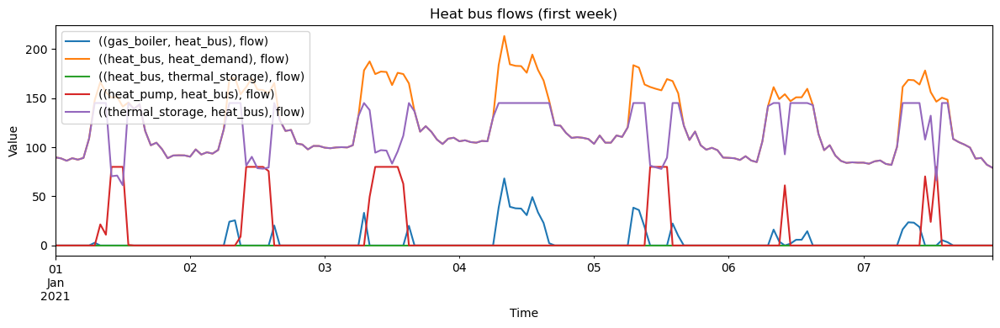

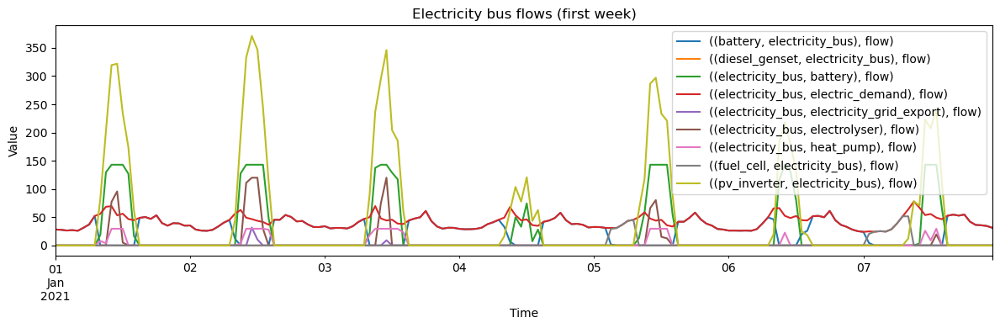

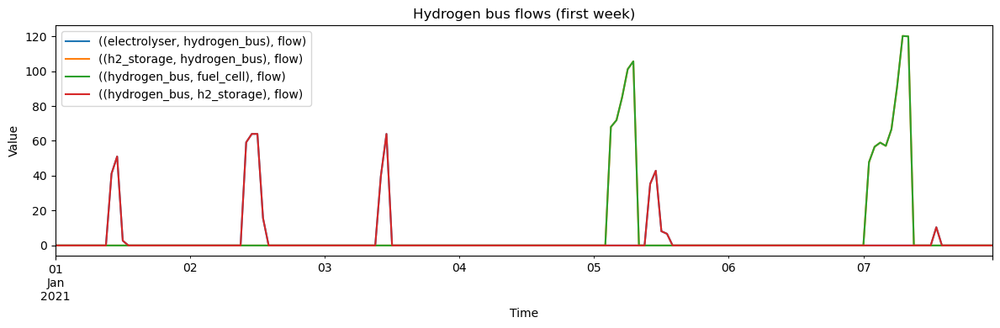

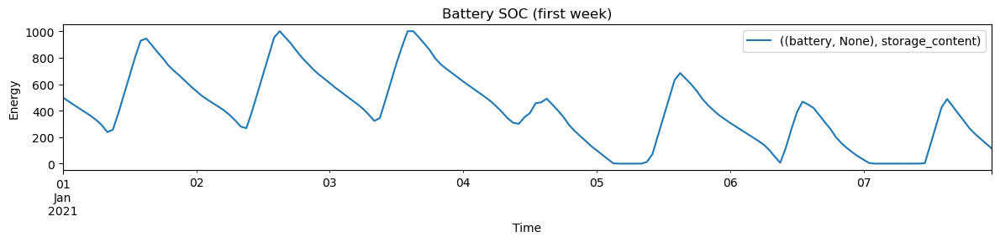

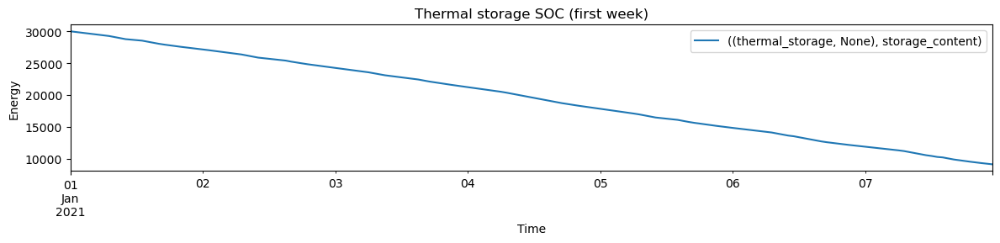

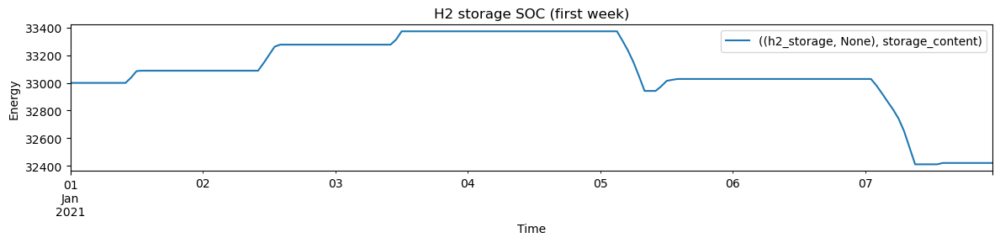

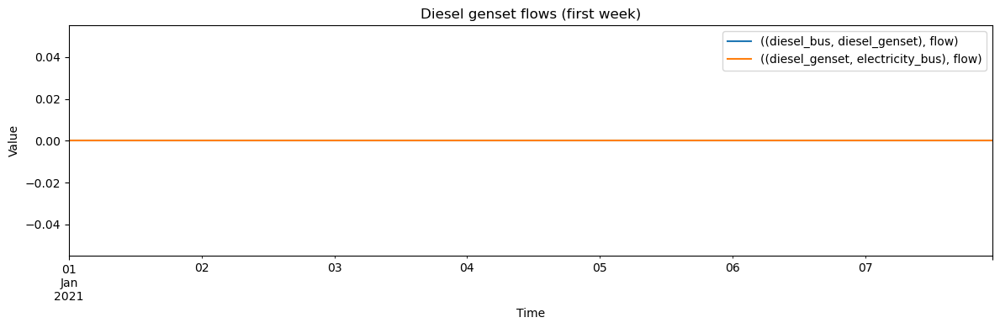

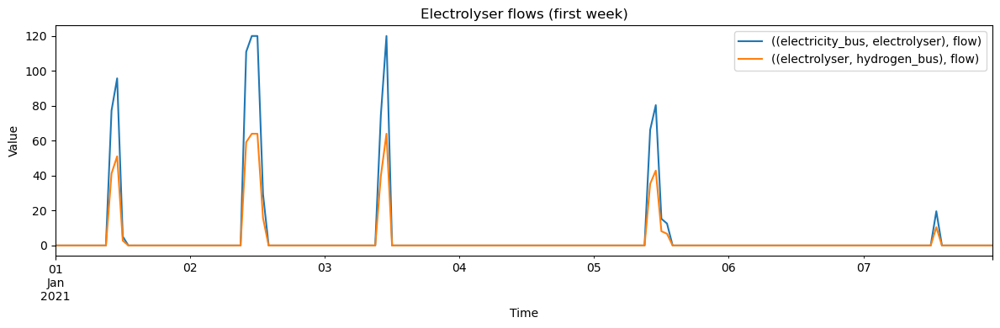

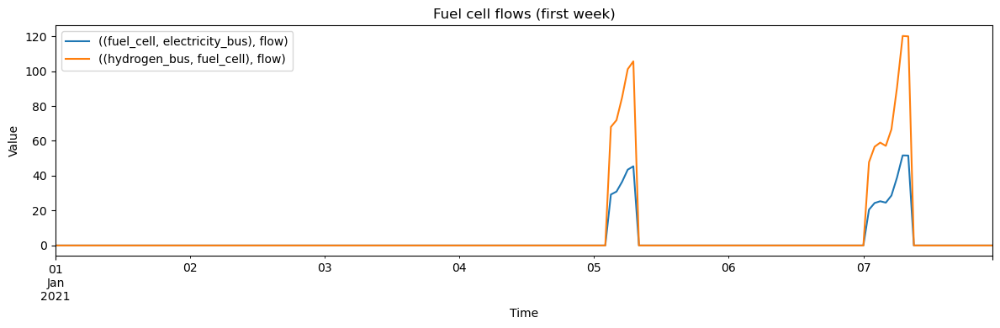

In [35]:
plot_node("heat_bus", title="Heat bus flows (first week)", n_hours=168)       
plot_node("electricity_bus", title="Electricity bus flows (first week)", n_hours=168)
plot_node("hydrogen_bus", title="Hydrogen bus flows (first week)", n_hours=168)

plot_storage_soc("battery", title="Battery SOC (first week)", n_hours=168)
plot_storage_soc("thermal_storage", title="Thermal storage SOC (first week)", n_hours=168)
plot_storage_soc("h2_storage", title="H2 storage SOC (first week)", n_hours=168)

plot_node("diesel_genset", title="Diesel genset flows (first week)", n_hours=168)
plot_node("electrolyser", title="Electrolyser flows (first week)", n_hours=168)
plot_node("fuel_cell", title="Fuel cell flows (first week)", n_hours=168)

#### Hydrogen storage charge and discharge summary

In [36]:
h2_seq = views.node(results, "h2_storage")["sequences"]
in_col  = (("hydrogen_bus", "h2_storage"), "flow")
out_col = (("h2_storage", "hydrogen_bus"), "flow")

h2_in  = h2_seq[in_col]
h2_out = h2_seq[out_col]
print("H2 charged (kWh-equiv):", float(h2_in.sum()))
print("H2 discharged (kWh-equiv):", float(h2_out.sum()))
print("Max H2 in (kW):", float(h2_in.max()))
print("Max H2 out (kW):", float(h2_out.max()))

net = float(h2_in.sum()) - float(h2_out.sum())
share = 100 * net / float(h2_in.sum()) 
print("Net H2 accumulation (kWh-equiv):", net)
print("Net share of charged (%):", share)

H2 charged (kWh-equiv): 151411.47358134895
H2 discharged (kWh-equiv): 140812.67037911998
Max H2 in (kW): 63.996
Max H2 out (kW): 214.75044
Net H2 accumulation (kWh-equiv): 10598.80320222897
Net share of charged (%): 7.000000034036089


#### Electrolyser utilisation statistics

In [37]:
el_in = views.node(results, "electrolyser")["sequences"][(("electricity_bus","electrolyser"),"flow")]
print("Electrolyser max (kW):", float(el_in.max()))
print("Hours > 400kW:", int((el_in > 400).sum()))
print("Electrolyser annual energy (kWh):", float(el_in.sum()))

Electrolyser max (kW): 120.0
Hours > 400kW: 0
Electrolyser annual energy (kWh): 283914.25758746


#### Boiler usage and contribution

In [38]:
boiler_out = views.node(results, "gas_boiler")["sequences"][(("gas_boiler","heat_bus"),"flow")]

thr = 1e-3 
boiler_hours = int((boiler_out > thr).sum())

print("Boiler operating hours (h):", boiler_hours)
print("Boiler full-load hours (h):", float(boiler_out.sum()) / float(boiler_power_kwth) if float(boiler_out.max()) > 0 else 0.0)

Boiler operating hours (h): 1547
Boiler full-load hours (h): 798.5600021874001


In [39]:
ed = views.node(results, "electric_demand")["sequences"]
print("Unmet demand? max abs:", float((ed.sum(axis=1) - ed.sum(axis=1)).abs().max()))


Unmet demand? max abs: 0.0


In [40]:
fc = views.node(results, "fuel_cell")["sequences"]
fc_out = fc[(('fuel_cell','electricity_bus'),'flow')]
print("Fuel cell max output:", fc_out.max())

Fuel cell max output: 92.342691


In [41]:
def storage_soc(results, storage_label: str):
    seq = views.node(results, storage_label)["sequences"]
    for c in seq.columns:
        if (
            isinstance(c, tuple) and len(c) == 2 and c[1] == "storage_content"
            and isinstance(c[0], tuple) and len(c[0]) == 2
            and c[0][0] == storage_label
        ):
            return seq[c]
    raise KeyError(f"No storage_content column found for {storage_label}. Columns: {list(seq.columns)}")


print("===== Yearly Values (AC on electricity_bus) =====")
el_demand = flow(results, "electricity_bus", "electric_demand")
el_demand_year_kwh = float(el_demand.sum())

pv_ac = flow(results, "pv_inverter", "electricity_bus")
pv_year_kwh = float(pv_ac.sum())

fc_out = flow(results, "fuel_cell", "electricity_bus")
fc_year_kwh = float(fc_out.sum())

diesel_out = flow(results, "diesel_genset", "electricity_bus")
diesel_year_kwh = float(diesel_out.sum())

print("Year electricity demand (kWh):", el_demand_year_kwh)
print("PV AC delivered (kWh):", pv_year_kwh)
print("Fuel cell electricity (kWh):", fc_year_kwh)
print("Diesel electricity (kWh):", diesel_year_kwh)

# Fuel cell saturation
fc_max = float(fc_out.max())
fc_hours_near_max = int((fc_out >= 0.99 * fc_max).sum())
print("Fuel cell max (kW):", fc_max)
print("Hours fuel cell near max:", fc_hours_near_max)

# H2 storage SOC
h2_soc = storage_soc(results, "h2_storage")
print("H2 SOC min/max:", float(h2_soc.min()), float(h2_soc.max()))
print("H2 SOC min date:", h2_soc.idxmin())
print("H2 SOC max date:", h2_soc.idxmax())

# Diesel operating hours
diesel_hours = int((diesel_out > 0.1).sum())
print("Diesel operating hours (>0.1 kW):", diesel_hours)

===== Yearly Values (AC on electricity_bus) =====
Year electricity demand (kWh): 341933.6575554274
PV AC delivered (kWh): 1644475.18187688
Fuel cell electricity (kWh): 60549.44829406999
Diesel electricity (kWh): 0.0
Fuel cell max (kW): 92.342691
Hours fuel cell near max: 2
H2 SOC min/max: 26235.802 165000.0
H2 SOC min date: 2021-02-04 08:00:00
H2 SOC max date: 2021-10-15 13:00:00
Diesel operating hours (>0.1 kW): 0


In [42]:
print("Fuel cell nominal_value you set:", fuel_cell_power_el_kw)

Fuel cell nominal_value you set: 100.0


## Economics: CAPEX / OPEX / LCOE / LCOH

In [43]:
def flow_series(results, frm: str, to: str) -> pd.Series:
    """
    Read a flow time series from solph results with your column format:
    (('from','to'), 'flow')
    """
    seq = views.node(results, frm)["sequences"]
    key = ((frm, to), "flow")
    if key not in seq.columns:
        raise KeyError(
            f"Flow column not found: {key}\n"
            f"Available columns (first 15): {list(seq.columns)[:15]}"
        )
    return seq[key]

def safe_yearly_kwh_flow(results, frm: str, to: str) -> float:
    try:
        return float(flow_series(results, frm, to).sum())  # hourly => kWh
    except KeyError:
        return 0.0

def yearly_kwh(series_kw: pd.Series) -> float:
    return float(series_kw.sum())  # hourly => kWh

def annuity_factor(i: float, n: int) -> float:
    if i == 0:
        return 1.0 / n
    return (i * (1 + i) ** n) / ((1 + i) ** n - 1)

def annualized_capex(upfront_cost_eur: float, interest_rate: float, lifetime_years: int) -> float:
    return float(upfront_cost_eur) * annuity_factor(float(interest_rate), int(lifetime_years))


####  Read annual delivered energies

In [44]:
E_el_load_kwh = yearly_kwh(flow_series(results, "electricity_bus", "electric_demand"))
E_th_load_kwh = yearly_kwh(flow_series(results, "heat_bus", "heat_demand"))

#### Fuel OPEX 

In [45]:
E_diesel_in_kwh = safe_yearly_kwh_flow(results, "diesel_supply", "diesel_bus")
E_gas_in_kwh    = safe_yearly_kwh_flow(results, "gas_supply", "gas_bus")

OPEX_el_fuel_eur = E_diesel_in_kwh * diesel_price_eur_per_kwh
OPEX_th_fuel_eur = E_gas_in_kwh    * gas_price_eur_per_kwh
OPEX_fuel_total_eur = OPEX_el_fuel_eur + OPEX_th_fuel_eur

In [46]:
interest_rate = 0.06

life_pv           = 25
life_inverter     = 10
life_battery      = 15
life_hp           = 25
life_boiler       = 20
life_electrolyser = 20
life_fuelcell     = 20
life_h2_storage   = 20
life_th_storage   = 25
life_diesel       = 25

In [47]:
capex_pv_roof_eur_per_kw   = 800.0
capex_pv_ground_eur_per_kw = 700.0
capex_pv_eur_per_kw = 664.0

# Inverter
capex_inverter_eur_per_kw = 47.0

# Battery
capex_battery_eur_per_kwh = 200.0

# Heat pump
subsidy_hp_fraction = 0.55
capex_hp_gross_eur_per_kwth = 4000.0
capex_hp_eur_per_kwth = capex_hp_gross_eur_per_kwth * (1 - subsidy_hp_fraction)

# Boiler
capex_boiler_eur_per_kwth = 74.0

# Hydrogen components
capex_electrolyser_eur_per_kw = 2290.0
capex_fuelcell_eur_per_kw     = 1836.5
capex_h2_storage_eur_per_kwh  = 0.451

# Thermal storage
subsidy_th_storage_fraction = 0.55
th_storage_grant_eur = 2500.0
capex_th_storage_gross_eur_per_kwh = 8.0

# Diesel genset
CAPEX_diesel_eur_fixed = 11000.0

# Fixed O&M
fixed_om_fraction = 0.02

#### Upfront CAPEX by component

In [48]:
# --- PV ---
CAPEX_pv_eur = pv_peak_power_kw * capex_pv_eur_per_kw  

# --- Inverter ---
CAPEX_inverter_eur = inverter_ac_limit_kw * capex_inverter_eur_per_kw

# --- Battery ---
CAPEX_battery_eur = battery_capacity_kwh * capex_battery_eur_per_kwh

# --- Heat pump + boiler ---
CAPEX_hp_eur = heat_pump_power_kwth * capex_hp_eur_per_kwth          
CAPEX_boiler_eur = boiler_power_kwth * capex_boiler_eur_per_kwth

# --- Hydrogen system ---
CAPEX_electrolyser_eur = electrolyser_power_in_kw * capex_electrolyser_eur_per_kw
CAPEX_fuelcell_eur     = fuel_cell_power_el_kw   * capex_fuelcell_eur_per_kw
CAPEX_h2_storage_eur   = h2_storage_capacity_kwh * capex_h2_storage_eur_per_kwh

# --- Thermal storage (gross -> net with 55% subsidy + 2500€ grant) ---
CAPEX_th_storage_gross = thermal_storage_capacity_kwh * capex_th_storage_gross_eur_per_kwh
CAPEX_th_storage_eur = max(
    0.0,
    CAPEX_th_storage_gross * (1 - subsidy_th_storage_fraction) - th_storage_grant_eur
)

# --- Diesel genset ---
CAPEX_diesel_eur = CAPEX_diesel_eur_fixed 

# --- Total upfront CAPEX ---
CAPEX_total_upfront_eur = (
    CAPEX_pv_eur + CAPEX_inverter_eur
    + CAPEX_battery_eur + CAPEX_hp_eur + CAPEX_boiler_eur
    + CAPEX_electrolyser_eur + CAPEX_fuelcell_eur + CAPEX_h2_storage_eur
    + CAPEX_th_storage_eur + CAPEX_diesel_eur
)


#### Annualized CAPEX

In [49]:
CAPEX_annual_eur = (
    annualized_capex(CAPEX_pv_eur, interest_rate, life_pv)
    + annualized_capex(CAPEX_inverter_eur, interest_rate, life_inverter)
    + annualized_capex(CAPEX_battery_eur, interest_rate, life_battery)
    + annualized_capex(CAPEX_hp_eur, interest_rate, life_hp)
    + annualized_capex(CAPEX_boiler_eur, interest_rate, life_boiler)
    + annualized_capex(CAPEX_electrolyser_eur, interest_rate, life_electrolyser)
    + annualized_capex(CAPEX_fuelcell_eur, interest_rate, life_fuelcell)
    + annualized_capex(CAPEX_h2_storage_eur, interest_rate, life_h2_storage)
    + annualized_capex(CAPEX_th_storage_eur, interest_rate, life_th_storage)
    + annualized_capex(CAPEX_diesel_eur, interest_rate, life_diesel)
)


#### Fixed O&M OPEX and total annual cost

In [50]:
OPEX_fixed_om_eur = fixed_om_fraction * CAPEX_total_upfront_eur
OPEX_total_eur = OPEX_fuel_total_eur + OPEX_fixed_om_eur + grid_maintenance_eur_per_year
Total_annual_cost_eur = CAPEX_annual_eur + OPEX_total_eur

#### LCOE/LCOH methods

In [51]:
# System-level
LCOE_system_eur_per_kwh = Total_annual_cost_eur / E_el_load_kwh
LCOH_system_eur_per_kwh = Total_annual_cost_eur / E_th_load_kwh

# Energy-share allocation 
E_total_kwh = E_el_load_kwh + E_th_load_kwh
share_el = E_el_load_kwh / E_total_kwh
share_th = E_th_load_kwh / E_total_kwh

LCOE_alloc_eur_per_kwh = (Total_annual_cost_eur * share_el) / E_el_load_kwh
LCOH_alloc_eur_per_kwh = (Total_annual_cost_eur * share_th) / E_th_load_kwh
LCOE_overall_eur_per_kwh = Total_annual_cost_eur / E_total_kwh

# Asset-based allocation
CAPEX_el_upfront = (
    CAPEX_pv_eur + CAPEX_inverter_eur + CAPEX_battery_eur + CAPEX_electrolyser_eur
    + CAPEX_fuelcell_eur + CAPEX_h2_storage_eur + CAPEX_diesel_eur
)

CAPEX_th_upfront = CAPEX_hp_eur + CAPEX_boiler_eur + CAPEX_th_storage_eur

CAPEX_el_annual = (
    annualized_capex(CAPEX_pv_eur, interest_rate, life_pv)
    + annualized_capex(CAPEX_inverter_eur, interest_rate, life_inverter)
    + annualized_capex(CAPEX_battery_eur, interest_rate, life_battery)
    + annualized_capex(CAPEX_electrolyser_eur, interest_rate, life_electrolyser)
    + annualized_capex(CAPEX_fuelcell_eur, interest_rate, life_fuelcell)
    + annualized_capex(CAPEX_h2_storage_eur, interest_rate, life_h2_storage)
    + annualized_capex(CAPEX_diesel_eur, interest_rate, life_diesel)
)

CAPEX_th_annual = (
    annualized_capex(CAPEX_hp_eur, interest_rate, life_hp)
    + annualized_capex(CAPEX_boiler_eur, interest_rate, life_boiler)
    + annualized_capex(CAPEX_th_storage_eur, interest_rate, life_th_storage)
)

#### OPEX allocation

In [52]:
OPEX_el_fixed = fixed_om_fraction * CAPEX_el_upfront
OPEX_th_fixed = fixed_om_fraction * CAPEX_th_upfront

Cost_el_annual = CAPEX_el_annual + OPEX_el_fuel_eur + OPEX_el_fixed + grid_maintenance_eur_per_year
Cost_th_annual = CAPEX_th_annual + OPEX_th_fuel_eur + OPEX_th_fixed

LCOE_asset_eur_per_kwh = Cost_el_annual / E_el_load_kwh
LCOH_asset_eur_per_kwh = Cost_th_annual / E_th_load_kwh


In [53]:
Total_annual_cost_net_eur = Total_annual_cost_eur + grid_maintenance_eur_per_year - export_revenue_eur

LCOE_system_net_eur_per_kwh = (
    Total_annual_cost_net_eur / E_el_load_kwh if E_el_load_kwh > 1e-12 else float("nan")
)
LCOH_system_net_eur_per_kwh = (
    Total_annual_cost_net_eur / E_th_load_kwh if E_th_load_kwh > 1e-12 else float("nan")
)
LCOE_overall_net_eur_per_kwh = Total_annual_cost_net_eur / E_total_kwh


summary_main = pd.DataFrame({
    "Metric": [
        "Annual electricity load (kWh)",
        "Annual heat load (kWh_th)",
        "Diesel input energy (kWh)",
        "Gas input energy (kWh)",
        "Fuel OPEX total (€/yr)",
        "Upfront CAPEX total (€, sum components)",
        "Annualized CAPEX (€/yr)",
        "Fixed O&M OPEX (€/yr)",
        "Total OPEX (€/yr)",
        "Total annual cost (€/yr)",

        # --- Grid export / maintenance ---
        "Export energy (kWh/yr)",
        "Export revenue (€/yr)",
        "Grid maintenance (€/yr)",
        "Net grid impact (maintenance - revenue) (€/yr)",

        # --- Net totals ---
        "Total annual cost NET (€/yr)",

        # --- LCOE/LCOH (gross and net) ---
        "LCOE system (€/kWh_el)",
        "LCOH system (€/kWh_th)",
        "LCOE system NET (€/kWh_el)",
        "LCOH system NET (€/kWh_th)",
        "LCOE overall (€/kWh_energy)",
        "LCOE overall NET (€/kWh_energy)",

        # --- Existing allocations ---
        "LCOE allocated (€/kWh_el)",
        "LCOH allocated (€/kWh_th)",
        "LCOE asset-based (€/kWh_el)",
        "LCOH asset-based (€/kWh_th)",
        "Energy-share electricity",
        "Energy-share heat",
    ],
    "Value": [
        E_el_load_kwh,
        E_th_load_kwh,
        E_diesel_in_kwh,
        E_gas_in_kwh,
        OPEX_fuel_total_eur,
        CAPEX_total_upfront_eur,
        CAPEX_annual_eur,
        OPEX_fixed_om_eur,
        OPEX_total_eur,
        Total_annual_cost_eur,

        # grid terms
        export_kwh,
        export_revenue_eur,
        grid_maintenance_eur_per_year,
        grid_maintenance_eur_per_year - export_revenue_eur,

        # net total
        Total_annual_cost_net_eur,

        # lcoe/lcoh
        LCOE_system_eur_per_kwh,
        LCOH_system_eur_per_kwh,
        LCOE_system_net_eur_per_kwh,
        LCOH_system_net_eur_per_kwh,
        LCOE_overall_eur_per_kwh,
        LCOE_overall_net_eur_per_kwh,

        # existing
        LCOE_alloc_eur_per_kwh,
        LCOH_alloc_eur_per_kwh,
        LCOE_asset_eur_per_kwh,
        LCOH_asset_eur_per_kwh,
        share_el,
        share_th,
    ]
})

capex_components = pd.DataFrame({
    "Component": [
        "PV", "Inverter", "Battery", "Heat pump", "Boiler",
        "Electrolyser", "Fuel cell", "H2 storage",
        "Thermal storage", "Diesel genset"
    ],
    "Upfront CAPEX (€)": [
        CAPEX_pv_eur, CAPEX_inverter_eur,
        CAPEX_battery_eur, CAPEX_hp_eur, CAPEX_boiler_eur,
        CAPEX_electrolyser_eur, CAPEX_fuelcell_eur, CAPEX_h2_storage_eur,
        CAPEX_th_storage_eur, CAPEX_diesel_eur
    ]
}).sort_values("Upfront CAPEX (€)", ascending=False)

print(summary_main.to_string(index=False))
print("\n--- Upfront CAPEX by component (descending) ---")
print(capex_components.to_string(index=False))


                                        Metric         Value
                 Annual electricity load (kWh)  3.419337e+05
                     Annual heat load (kWh_th)  5.847058e+05
                     Diesel input energy (kWh)  0.000000e+00
                        Gas input energy (kWh)  1.274298e+05
                        Fuel OPEX total (€/yr)  1.047473e+04
       Upfront CAPEX total (€, sum components)  2.133195e+06
                       Annualized CAPEX (€/yr)  1.792665e+05
                         Fixed O&M OPEX (€/yr)  4.266390e+04
                             Total OPEX (€/yr)  5.313863e+04
                      Total annual cost (€/yr)  2.324051e+05
                        Export energy (kWh/yr)  8.851630e+05
                         Export revenue (€/yr)  5.948296e+04
                       Grid maintenance (€/yr)  0.000000e+00
Net grid impact (maintenance - revenue) (€/yr) -5.948296e+04
                  Total annual cost NET (€/yr)  1.729222e+05
                        